# **Amazon Fine Food Reviews - Exploratory Data Analysis**

### Project : Fake Review Detection & Sentiment Analysis
### Dataset : Amazon Fine Food Reviews(kaggle)

### Goal : Understand pattern in reviews to build a fake review detector


# 1. Import Libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os


import re
import string
from collections import Counter
from wordcloud import WordCloud

# Text
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download("wordnet")


COLORS = {
    'primary'  : '#2196F3',   # main blue
    'light'    : '#90CAF9',   # light blue
    'dark'     : '#1565C0',   # dark blue
    'muted'    : '#B0BEC5',   # grey
    'white'    : '#FFFFFF',
}

RATING_COLORS = [
    '#90CAF9',   # 1 star - light blue
    '#64B5F6',   # 2 star
    '#2196F3',   # 3 star - medium blue
    '#1976D2',   # 4 star
    '#1565C0',   # 5 star - dark blue
]

SENT_COLORS = {
    'Positive' : '#1976D2',   # blue
    'Neutral'  : '#90CAF9',   # light blue
    'Negative' : '#B0BEC5',   # grey
}

# ── Clean Style ──────────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.edgecolor'    : '#E0E0E0',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.titlecolor'   : '#212121',
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'xtick.color'       : '#757575',
    'ytick.color'       : '#757575',
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'grid.color'        : '#E0E0E0',
    'font.family'       : 'sans-serif',
})



print('✅ All libraries imported successfully!')

os.makedirs("outputs" , exist_ok=True)
os.makedirs("models_output",exist_ok=True)


# save plots
def models_output(filename):
  plt.savefig(f"models_output/{filename}.png",
              dpi=150,
              bbox_inches="tight")


# save plots
def save_plots(filename):
  plt.savefig(f"outputs/{filename}.png",
              dpi=150,
              bbox_inches="tight"

  )
  plt.show()

def apply_base_style(axes):
  axes.set_facecolor("#F8F9FA")
  axes.set_facecolor("white")
  for spine in axes.spines.values():
    spine.set_edgecolor("#CCCCCC")
  axes.grid(axis="y" , color="#CCCCCC",
          alpha=0.5,linestyle="--")

  axes.tick_params(colors="#444444")


✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 2. Load Dataset

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


In [6]:
import os
os.listdir("/kaggle/input/amazon-fine-food-reviews")


['hashes.txt', 'Reviews.csv', 'database.sqlite']

In [7]:
df=pd.read_csv("/kaggle/input/amazon-fine-food-reviews/Reviews.csv")


In [8]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

# 🎯 3. Basic Info & Data Quality

In [10]:
print("="*50)
print("Dataset info")
print("="*50)
df.info()

print("\n" + "="*50)
print("Missing values")
print("="*50)

missing=df.isnull().sum()
missing_percent=missing/len(df)*100
missing_df=pd.DataFrame({
    "missing_count" : missing,
    "missing %" : missing_percent
})

print("="*50)
print("Duplicate values")
print("="*50)
print(f"Duplicate rows:{df.duplicated().sum()}")
print(f"Duplicate reviews (same user_id + product_id): {df.duplicated(subset=["ProductId" , "UserId"])}")

Dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB

Missing values
Duplicate values
Duplicate rows:0
Duplicate reviews (same user_id + product_id): 0         False
1         False
2         False
3         False
4         False
          ..

# 4. 🎯   Data Cleaning

In [11]:
# drop duplicates rows
df.drop_duplicates(inplace=True)
df.dropna(subset=["Summary","Text"],inplace= True)

# convert time to datetime
df["ReviewDate"]=pd.to_datetime(df["Time"],unit="s")
df["Year"]=df["ReviewDate"].dt.year
df["Month"]=df["ReviewDate"].dt.month
df["DayOfWeek"]=df["ReviewDate"].dt.day_name()

#Review Length Features
df["Text_Length"]=df["Text"].apply(len)
df["WordCount"]=df["Text"].apply(lambda x: len(str(x).split()))
df["SummaryLength"]=df["Summary"].apply(len)

# Helpfullness Ratio
df["Helpfulness_Ratio"]=df.apply(
    lambda x :x["HelpfulnessNumerator"] / x["HelpfulnessDenominator"]
    if x["HelpfulnessDenominator"] > 0 else 0,axis=1)

print(f'✅ Clean dataset shape: {df.shape}')
df[['Score','Text_Length','WordCount','Helpfulness_Ratio','Year']].describe().round(2)

df["Sentiment"]=df["Score"].apply(lambda x: "positive" if x >=4
                                  else("Negative" if x <=2 else "Neutral"))

print(df["Sentiment"].value_counts())



✅ Clean dataset shape: (568427, 18)
Sentiment
positive    443777
Negative     82012
Neutral      42638
Name: count, dtype: int64


# 5. ⭐ Ratings Distribution Analysis

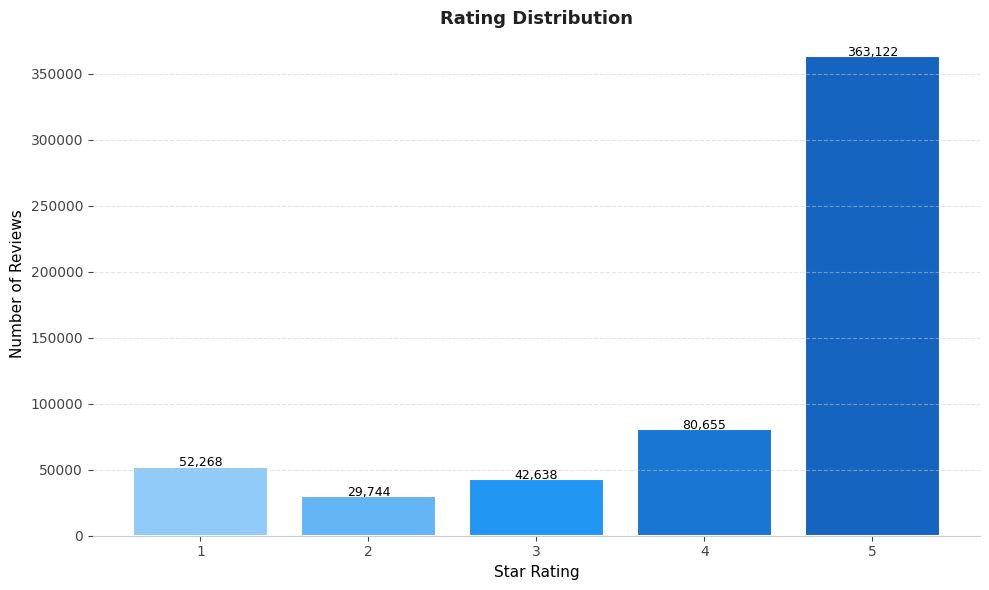

In [12]:
fig , ax =plt.subplots(figsize=(10,6))
apply_base_style(ax)
plt.rcParams.update()

# count plot
score_counts=df["Score"].value_counts().sort_index()
colors=RATING_COLORS

ax.bar(score_counts.index,score_counts.values,color=colors,
            edgecolor="white",linewidth=1.5)
ax.set_title("Rating Distribution")
ax.set_xlabel("Star Rating")
ax.set_ylabel("Number of Reviews")
for i,(idx,val) in enumerate(score_counts.items()):
  ax.text(idx,val+500,f"{val:,}",
            ha="center",fontsize=9)
plt.tight_layout()
save_plots("01_rating_distribution.png")


# 6.  📊 Reviews Over Year

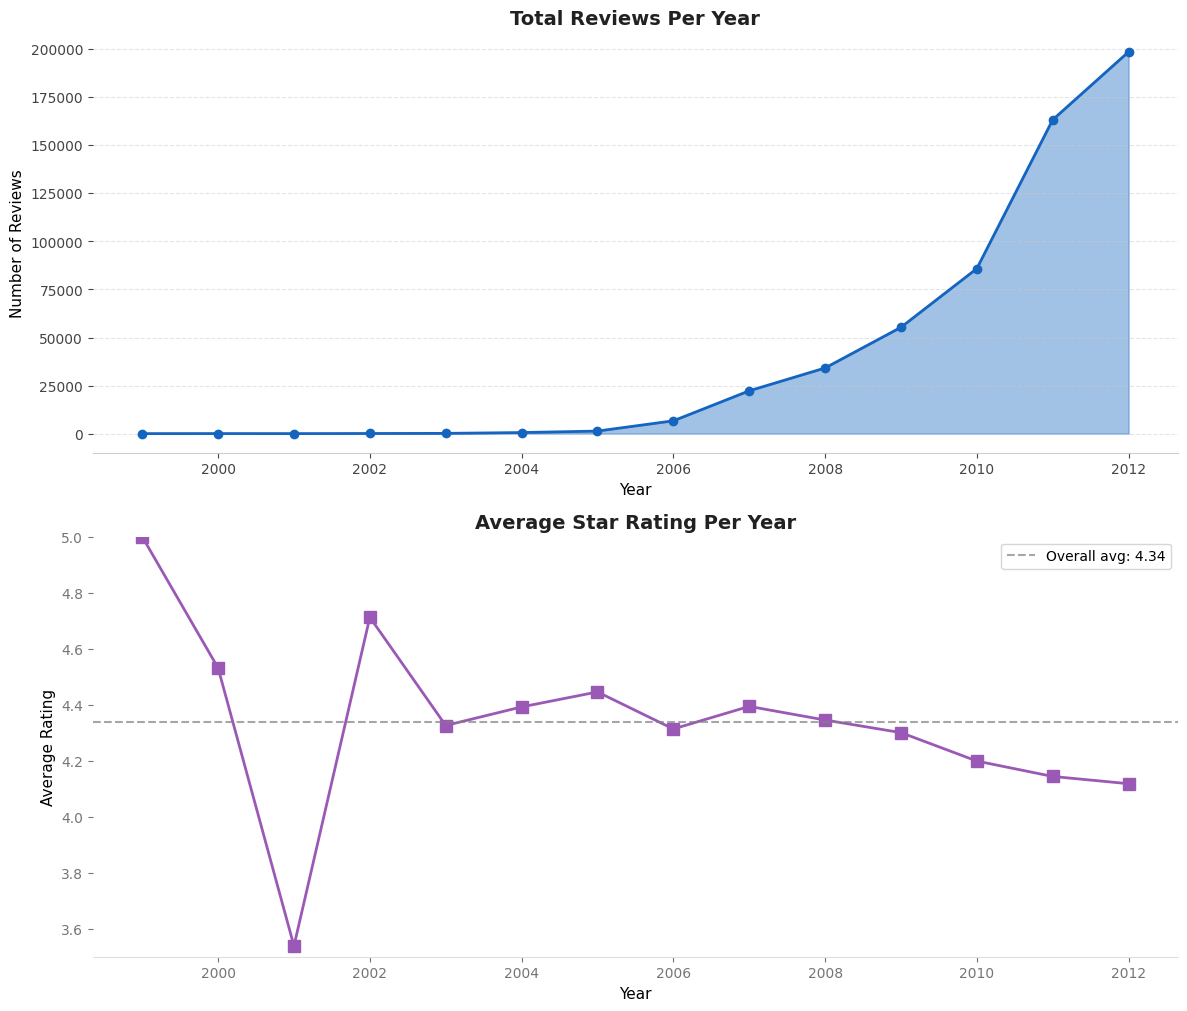

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
apply_base_style(axes[0])
plt.rcParams.update()

# Reviews per year
yearly = df.groupby('Year').size()
axes[0].fill_between(yearly.index, yearly.values, alpha=0.4, color='#1565C0')
axes[0].plot(yearly.index, yearly.values, 'o-', color="#1565C0", linewidth=2, markersize=6)
axes[0].set_title('Total Reviews Per Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Reviews')


# average rating per year
avg_rating_year=df.groupby("Year")["Score"].mean()
axes[1].plot(avg_rating_year.index, avg_rating_year.values, 's-', color='#9b59b6', linewidth=2, markersize=8)
axes[1].axhline(y=avg_rating_year.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Overall avg: {avg_rating_year.mean():.2f}')
axes[1].set_title('Average Star Rating Per Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.5, 5)
axes[1].legend()

save_plots("02_reviews_per_year")

# 7. 📊  Text Lenght Analysis

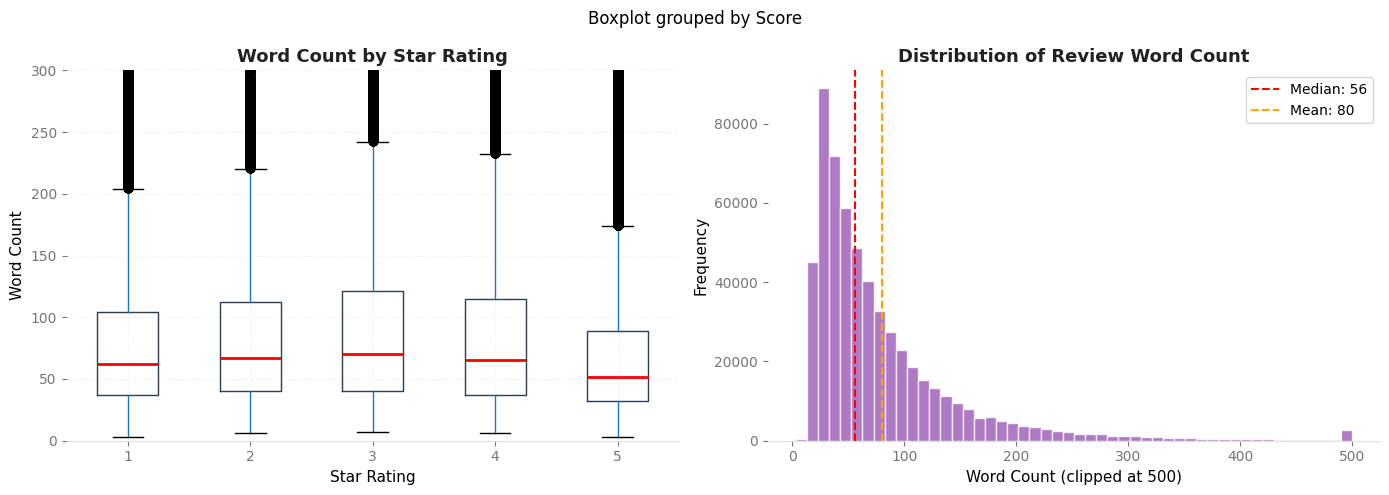


📊 Average word count by rating:
  1★ → 87.3 words
  2★ → 90.1 words
  3★ → 95.6 words
  4★ → 91.4 words
  5★ → 74.2 words


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word count by rating
df.boxplot(column='WordCount', by='Score', ax=axes[0],
           boxprops=dict(color='#2c3e50'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Word Count by Star Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Word Count')
axes[0].set_ylim(0, 300)
plt.sca(axes[0])
plt.title('Word Count by Star Rating')

# Word count distribution
axes[1].hist(df['WordCount'].clip(upper=500), bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axvline(df['WordCount'].median(), color='red', linestyle='--', label=f'Median: {df["WordCount"].median():.0f}')
axes[1].axvline(df['WordCount'].mean(), color='orange', linestyle='--', label=f'Mean: {df["WordCount"].mean():.0f}')
axes[1].set_title('Distribution of Review Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count (clipped at 500)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
save_plots("text_length_analysis")
plt.show()

# Insight
avg_by_score = df.groupby('Score')['WordCount'].mean()
print('\n📊 Average word count by rating:')
for score, avg in avg_by_score.items():
    print(f'  {score}★ → {avg:.1f} words')

# 8. 📊 User Behaviour Analysis

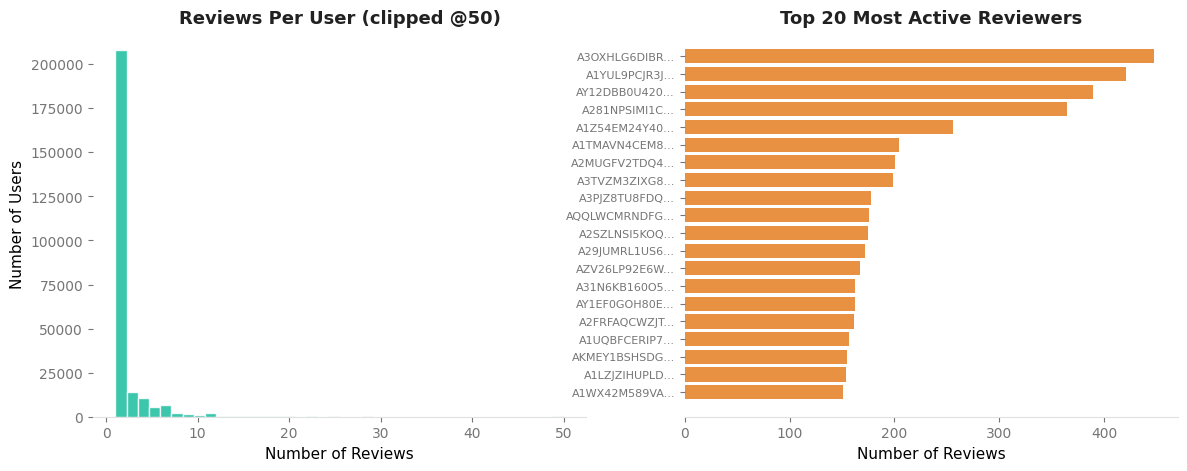

In [15]:
user_review_counts=df.groupby("UserId").size().reset_index(name="ReviewCount")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of reviews per user
axes[0].hist(user_review_counts['ReviewCount'].clip(upper=50), bins=40,
             color='#1abc9c', edgecolor='white', alpha=0.85)
axes[0].set_title('Reviews Per User (clipped @50)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')

# Top 20 prolific reviewers
top_users = user_review_counts.nlargest(20, 'ReviewCount')
axes[1].barh(range(20), top_users['ReviewCount'].values, color='#e67e22', alpha=0.85)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([uid[:12]+'...' for uid in top_users['UserId']], fontsize=8)
axes[1].set_title('Top 20 Most Active Reviewers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].invert_yaxis()

# 9. 🎯 Text Cleaning (NLP)

In [16]:
def clean_text(text):
  text=str(text).lower()
  text=re.sub(r'<[^>]+>',' ',text)
  text=re.sub(r'http\S+',' ', text)
  text=re.sub(r'[^a-z\s]',' ',text)
  text=re.sub(r'\s+',' ', text)

  # Tokenize
  lem=WordNetLemmatizer()
  sw=set(stopwords.words("english"))
  sw.update(["br","one","get","also","would","product","like"])

  tokens=word_tokenize(text)
  tokens=[lem.lemmatize(t) for t in tokens
          if t not in sw and len(t) > 2]

  return " ".join(tokens)
print("cleaning text")
df["CleanText"] = df["Text"].apply(clean_text)
print(df["CleanText"].iloc[0])

cleaning text
bought several vitality canned dog food product found good quality look stew processed meat smell better labrador finicky appreciates better


In [17]:
print(df["CleanText"].head())

0    bought several vitality canned dog food produc...
1    arrived labeled jumbo salted peanut peanut act...
2    confection around century light pillowy citrus...
3    looking secret ingredient robitussin believe f...
4    great taffy great price wide assortment yummy ...
Name: CleanText, dtype: object


#10. 📊 WordCloud

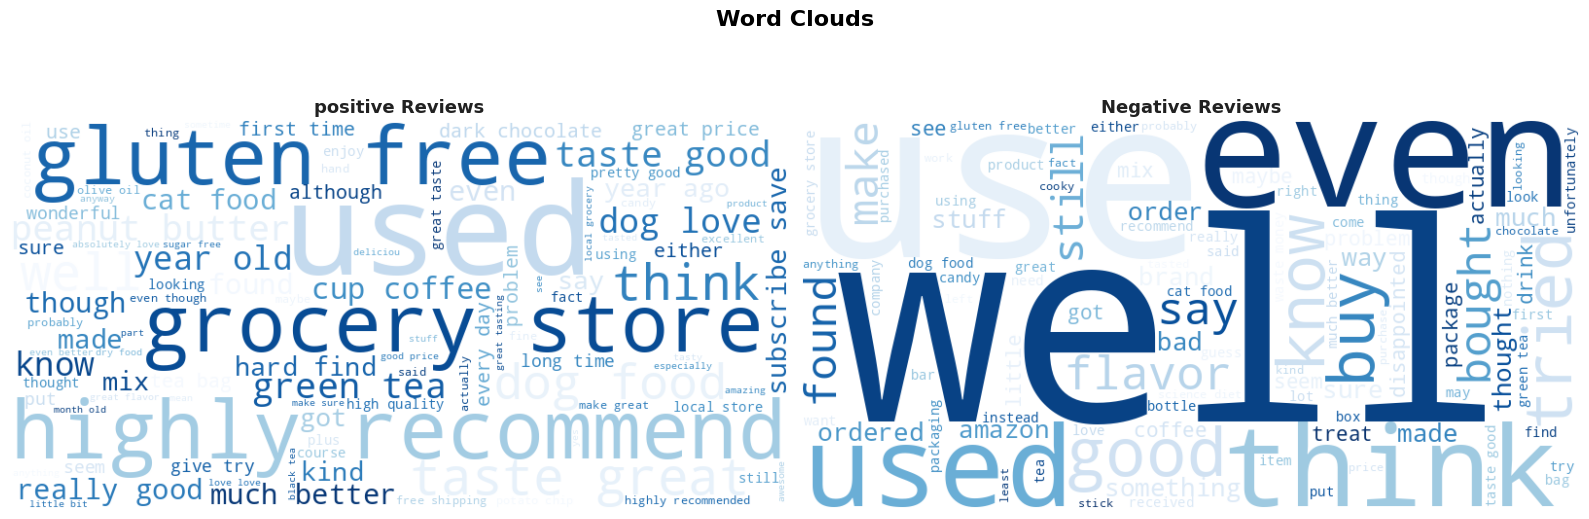

In [18]:
from wordcloud import WordCloud

def plot_word_cloud(df):
  fig , axes = plt.subplots(1,2,figsize=(16,6))
  configs=[
      ("positive","#1976D2",axes[0]),
      ("Negative","#90CAF9",axes[1])
  ]

  for sentiment, color , ax in configs:
    text=" ".join(
        df[df["Sentiment"] == sentiment]
        ["CleanText"].dropna()
    )
    wc=WordCloud(
        width=800, height=400,
        background_color="white",
        colormap="Blues",
        max_words=100
    ).generate(text)


    ax.imshow(wc,interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{sentiment} Reviews",
                 fontweight="bold")

  plt.suptitle("Word Clouds", fontsize=16,fontweight="bold")
  plt.tight_layout()
  save_plots("WordClouds")
plot_word_cloud(df)



# 11. 📊 Plot Top Words

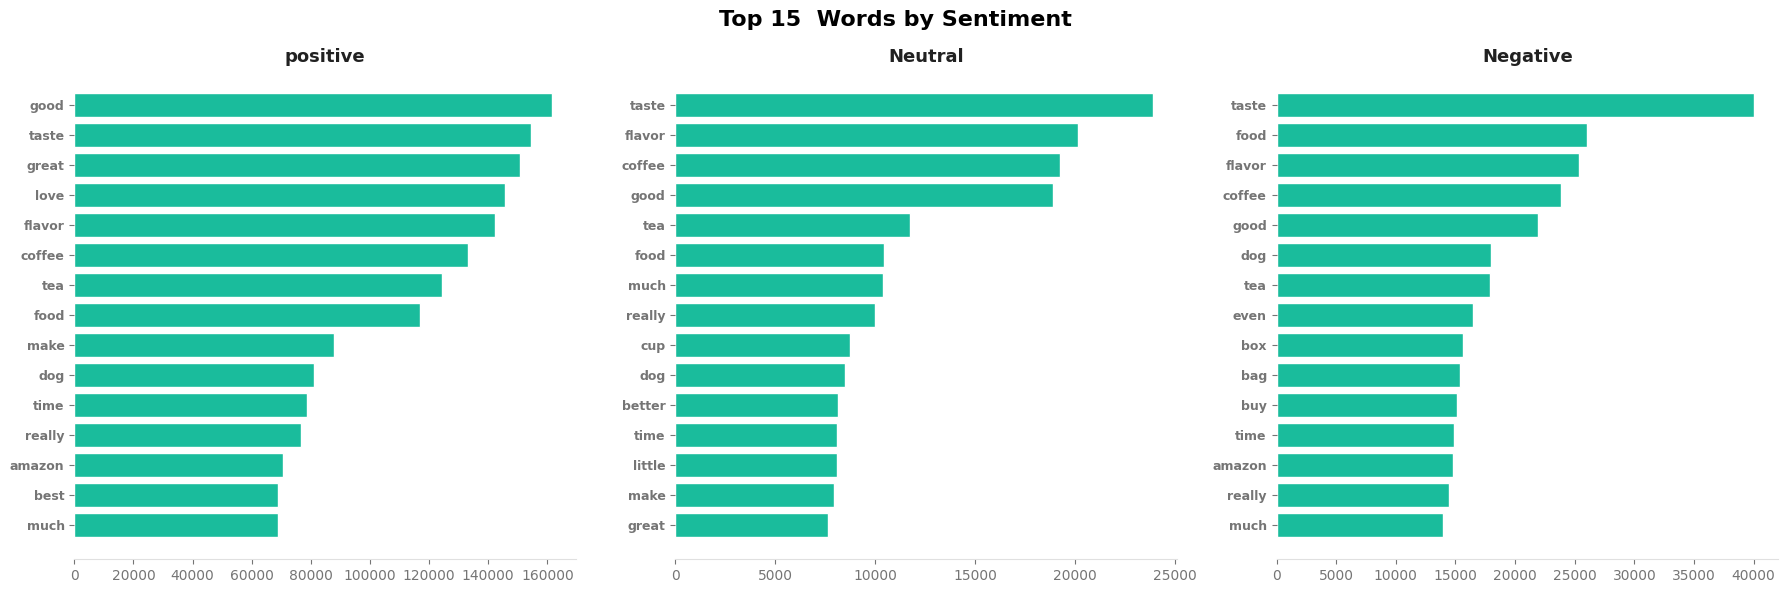

In [19]:
from collections import Counter

def plot_top_words(df,top_n=15):
  fig , axes=plt.subplots(1,3,figsize=(18,6))
  for ax , sent in zip(axes,["positive","Neutral","Negative"]):
    texts=df[df["Sentiment"]==sent]["CleanText"]
    words=" ".join(texts.dropna()).split()
    top=Counter(words).most_common(top_n)
    w , c = zip(*top)

    ax.barh(range(len(w)),c,color="#1abc9c",edgecolor="white")
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels(w,fontsize=9,fontweight="bold")
    ax.set_title(sent,fontweight="bold")
    ax.invert_yaxis()

  plt.suptitle("Top 15  Words by Sentiment",fontsize="16",fontweight="bold")
  plt.tight_layout()
  save_plots("05_highly_recommanded_words")
plot_top_words(df)




# 12. ⚔ TF-IDF + Model

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix,roc_curve,auc,
    precision_recall_curve, average_precision_score
)

In [21]:
def prepare_model(df):
  df_m=df[df["Sentiment"].isin(["positive","Negative"])].copy()
  df_m["Label"] = (
      df_m["Sentiment"]=="positive"
  ).astype(int)

  # TF-IDF
  tfidf=TfidfVectorizer(
      max_features=10000,
      min_df=2,
      ngram_range=(1,2)
  )
  X=tfidf.fit_transform(df_m["CleanText"])
  Y=df_m["Label"].values

  # Split
  X_train,X_test,Y_train,Y_test=train_test_split(
      X,Y,
      test_size=0.2,
      random_state=42,
      stratify=Y
  )


  # Model
  clf=LogisticRegression(
      max_iter=1000,
      class_weight="balanced"
  )
  clf.fit(X_train,Y_train)
  Y_pred=clf.predict(X_test)
  Y_prob=clf.predict_proba(X_test)[ :,1]

  print(f"Accuracy : {accuracy_score(Y_test,Y_pred):.4f}")
  print(f"\n {classification_report(Y_test,Y_pred)}")
  return clf, tfidf,X_test,Y_test , Y_pred,Y_prob

clf , tfidf , X_test, Y_test, Y_pred , Y_prob= prepare_model(df)



Accuracy : 0.9121

               precision    recall  f1-score   support

           0       0.66      0.91      0.76     16402
           1       0.98      0.91      0.95     88756

    accuracy                           0.91    105158
   macro avg       0.82      0.91      0.85    105158
weighted avg       0.93      0.91      0.92    105158



# 13. Confusion Matrix

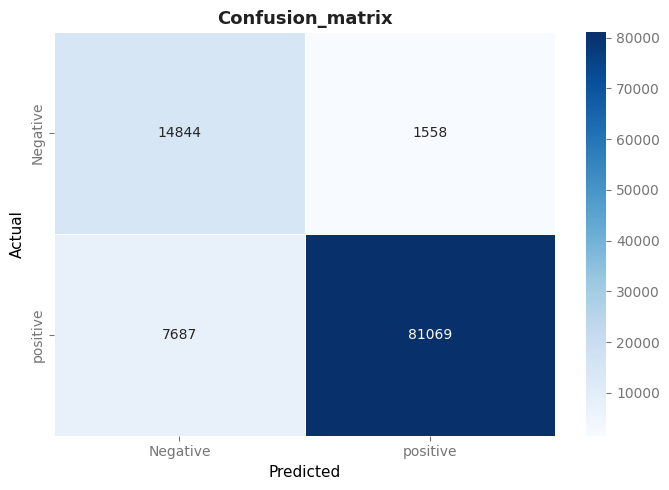

In [37]:
import seaborn as sns

def plot_confusion_matrix(Y_test,Y_pred):
  cm=confusion_matrix(Y_test,Y_pred)

  fig , ax = plt.subplots(figsize=(7,5))
  sns.heatmap(cm,annot=True,fmt="d",
              cmap="Blues",ax=ax,
              xticklabels=["Negative","positive"],
              yticklabels=["Negative","positive"],
              linewidth=0.5)
  ax.set_title("Confusion_matrix",fontweight="bold")
  ax.set_xlabel("Predicted")
  ax.set_ylabel("Actual")
  plt.tight_layout()
  models_output("confusion_matrix")

plot_confusion_matrix(Y_test,Y_pred)



#

# 14. 📊 ROC + PRC Curves

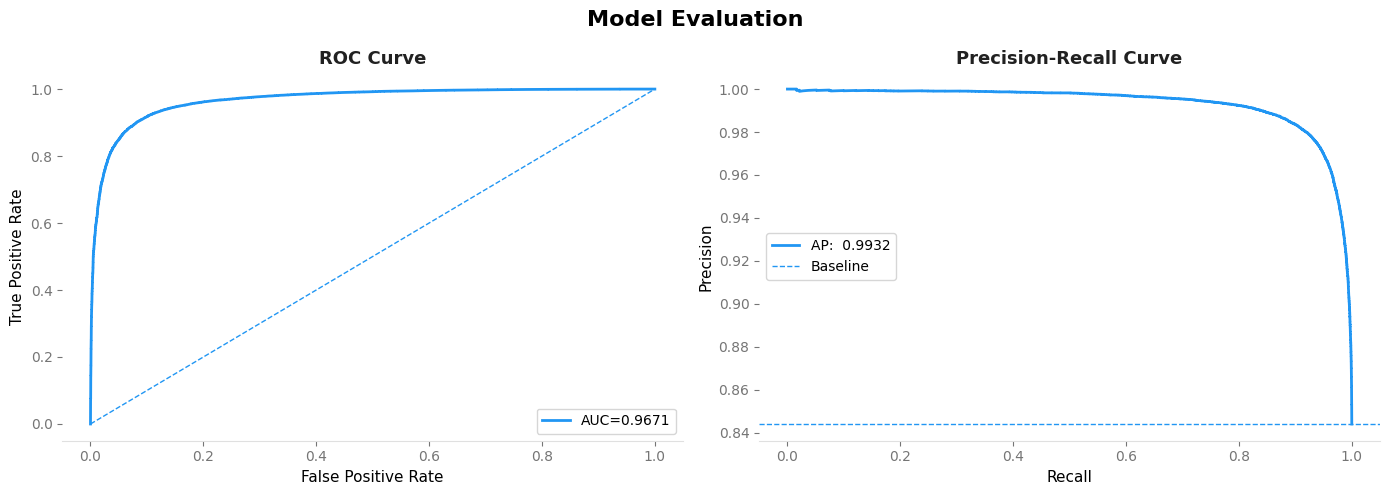

In [38]:
def plot_roc_prc(Y_test,Y_prob):
  fig , axes = plt.subplots(1,2, figsize=(14,5))
  # ROC Curve
  fpr ,tpr,_=roc_curve(Y_test,Y_prob)
  roc_auc=auc(fpr,tpr)
  axes[0].plot(fpr,tpr,
               color="#2196F3",lw=2,
               label=f"AUC={roc_auc:.4f}")
  axes[0].plot([0,1],[0,1],
               color="#2196F3",lw=1,
               linestyle="--")
  axes[0].set_title("ROC Curve",
                    fontweight="bold")
  axes[0].set_xlabel("False Positive Rate")
  axes[0].set_ylabel("True Positive Rate")
  axes[0].legend()

  # PRC Curve
  prec , rec,_ = precision_recall_curve(Y_test,Y_prob)
  ap=average_precision_score(Y_test,Y_prob)

  axes[1].plot(rec,prec,color="#2196F3",lw=2,
               label=f"AP: {ap: .4f}")
  axes[1].axhline(Y_test.mean(),
                  color="#2196F3",lw=1,
                  linestyle="--",label="Baseline")
  axes[1].set_title("Precision-Recall Curve",fontweight="bold")
  axes[1].set_xlabel("Recall")
  axes[1].set_ylabel("Precision")
  axes[1].legend()

  plt.suptitle("Model Evaluation",fontsize=16,fontweight="bold")
  plt.tight_layout()
  models_output("roc_prc_curve")

plot_roc_prc(Y_test,Y_prob)


In [32]:
def predict_review(text):
  cleaned=clean_text(text)
  X=tfidf.transform([cleaned])
  pred=clf.predict(X)[0]
  prob=clf.predict_proba(X)[0]

  if pred == 1:
    print(f" Positive ({prob[1]*100:.1f}%)")
  else:
    print(f" Negative({prob[0]*100:.1f}%)")
predict_review("very bad because waste of money on this tea")

 Negative(100.0%)


In [39]:
import joblib
joblib.dump(clf,"sentiment model.pkl")
joblib.dump(tfidf,"tfidf_vectorizer.pkl")


['tfidf_vectorizer.pkl']